
Circuit Diagram:


Measurement Counts:

{'10110': 927, '00110': 151, '10111': 194, '11010': 407, '00000': 294, '10100': 974, '10011': 230, '10000': 1880, '11110': 491, '11000': 502, '01000': 293, '01101': 41, '10010': 1133, '11101': 81, '00100': 176, '00111': 26, '01110': 233, '11100': 360, '01010': 208, '11111': 77, '01100': 170, '10001': 357, '00001': 57, '00010': 193, '10101': 178, '01011': 34, '11001': 97, '01001': 58, '00101': 32, '11011': 69, '00011': 31, '01111': 46}


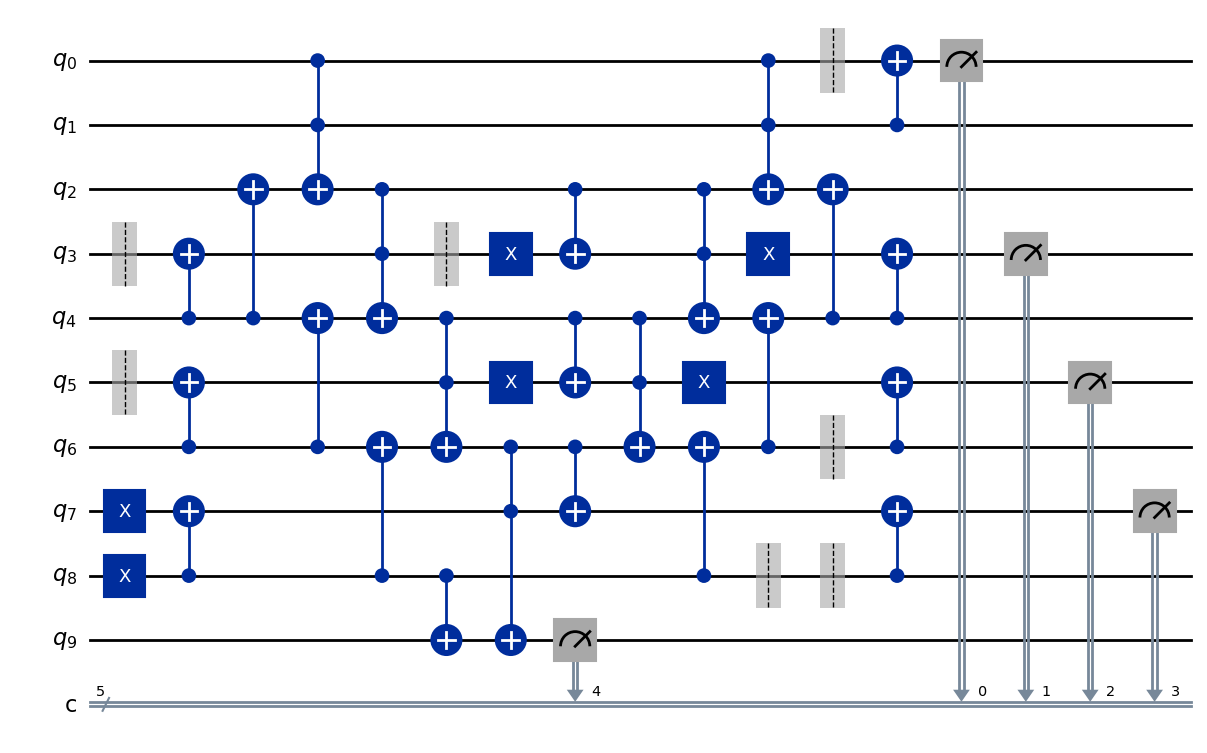

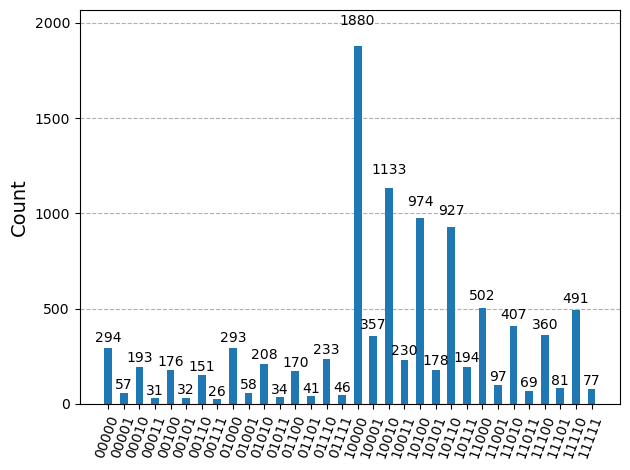


RESULTS

Correct Output: 10000

Correct Counts: 1880

Error Rate (ER): 81.2

NMED: 0.18223870967741934

MRED: 0.3530875

Success Rate:
18.8


In [10]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# =====================================================
# 4-BIT CUCCARO ADDER
# TEST CASE:
# 1000 + 1000 = 10000
# =====================================================

from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from numpy import pi

qreg_q = QuantumRegister(10, 'q')
creg_c = ClassicalRegister(5, 'c')
circuit = QuantumCircuit(qreg_q, creg_c)

circuit.x(qreg_q[7])
circuit.x(qreg_q[8])
circuit.barrier(qreg_q[3])
circuit.barrier(qreg_q[5])
circuit.cx(qreg_q[6], qreg_q[5])
circuit.cx(qreg_q[4], qreg_q[3])
circuit.cx(qreg_q[8], qreg_q[7])
circuit.cx(qreg_q[4], qreg_q[2])
circuit.ccx(qreg_q[0], qreg_q[1], qreg_q[2])
circuit.cx(qreg_q[6], qreg_q[4])
circuit.ccx(qreg_q[2], qreg_q[3], qreg_q[4])
circuit.cx(qreg_q[8], qreg_q[6])
circuit.ccx(qreg_q[4], qreg_q[5], qreg_q[6])
circuit.cx(qreg_q[8], qreg_q[9])
circuit.barrier(qreg_q[3])
circuit.x(qreg_q[3])
circuit.ccx(qreg_q[6], qreg_q[7], qreg_q[9])
circuit.x(qreg_q[5])
circuit.cx(qreg_q[2], qreg_q[3])
circuit.cx(qreg_q[4], qreg_q[5])
circuit.cx(qreg_q[6], qreg_q[7])
circuit.ccx(qreg_q[4], qreg_q[5], qreg_q[6])
circuit.ccx(qreg_q[2], qreg_q[3], qreg_q[4])
circuit.x(qreg_q[5])
circuit.cx(qreg_q[8], qreg_q[6])
circuit.ccx(qreg_q[0], qreg_q[1], qreg_q[2])
circuit.x(qreg_q[3])
circuit.cx(qreg_q[6], qreg_q[4])
circuit.barrier(qreg_q[8])
circuit.cx(qreg_q[4], qreg_q[2])
circuit.barrier(qreg_q[0])
circuit.barrier(qreg_q[6])
circuit.barrier(qreg_q[8])
circuit.cx(qreg_q[6], qreg_q[5])
circuit.cx(qreg_q[8], qreg_q[7])
circuit.cx(qreg_q[1], qreg_q[0])
circuit.cx(qreg_q[4], qreg_q[3])
circuit.measure(qreg_q[0], creg_c[0])
circuit.measure(qreg_q[3], creg_c[1])
circuit.measure(qreg_q[5], creg_c[2])
circuit.measure(qreg_q[7], creg_c[3])
circuit.measure(qreg_q[9], creg_c[4])

# ====================================================
# DRAW CIRCUIT
# ====================================================

print("\nCircuit Diagram:\n")
circuit.draw("mpl")

# ====================================================
# BITFLIP NOISE MODEL
# ====================================================

p = 0.037

# ----------------------------------------------------
# 1-Qubit Bitflip Error
# ----------------------------------------------------

error_1 = pauli_error([
    ('X', p),
    ('I', 1-p)
])

# ----------------------------------------------------
# 2-Qubit Error
# E ⊗ E
# ----------------------------------------------------

error_2 = error_1.tensor(error_1)

# ----------------------------------------------------
# 3-Qubit Error
# E ⊗ E ⊗ E
# ----------------------------------------------------

error_3 = error_1.tensor(error_1).tensor(error_1)

# ====================================================
# CREATE NOISE MODEL
# ====================================================

noise_model = NoiseModel()

# ----------------------------------------------------
# Apply noise to X gates
# ----------------------------------------------------

noise_model.add_all_qubit_quantum_error(
    error_1,
    ['x']
)

# ----------------------------------------------------
# Apply noise to CX gates
# ----------------------------------------------------

noise_model.add_all_qubit_quantum_error(
    error_2,
    ['cx']
)

# ----------------------------------------------------
# Apply noise to CCX gates
# ----------------------------------------------------

noise_model.add_all_qubit_quantum_error(
    error_3,
    ['ccx']
)

# ====================================================
# CREATE NOISY SIMULATOR
# ====================================================

sim = AerSimulator(noise_model=noise_model)

# ====================================================
# TRANSPILE CIRCUIT
# ====================================================

compiled = transpile(circuit, sim)

# ====================================================
# RUN SIMULATION
# ====================================================

shots = 10000

result = sim.run(
    compiled,
    shots=shots
).result()

counts = result.get_counts()

# ====================================================
# SHOW COUNTS
# ====================================================

print("\nMeasurement Counts:\n")
print(counts)

# ====================================================
# PLOT HISTOGRAM
# ====================================================

plot_histogram(counts)
plt.show()

# ====================================================
# ERROR RATE CALCULATION
# ====================================================

# Expected:
# 1000 + 1000 = 10000

# ====================================================
# ERROR METRICS
# ====================================================

correct_output = '10000'
correct_decimal = 16

D = 31  # Maximum possible output for 4-bit addition

# ----------------------------------------------------
# ERROR RATE (ER)
# ----------------------------------------------------

correct_counts = counts.get(correct_output, 0)

ER = 1 - (correct_counts / shots)

# ----------------------------------------------------
# CALCULATE ED, NMED, MRED
# ----------------------------------------------------

total_ED = 0
total_relative_ED = 0

for output, freq in counts.items():

    # Convert binary string to decimal
    noisy_decimal = int(output, 2)

    # Error Distance
    ED = abs(correct_decimal - noisy_decimal)

    # Accumulate weighted ED
    total_ED += ED * freq

    # Avoid divide-by-zero
    if correct_decimal != 0:
        total_relative_ED += (ED / correct_decimal) * freq

# ----------------------------------------------------
# MEAN ERROR DISTANCE
# ----------------------------------------------------

mean_ED = total_ED / shots

# ----------------------------------------------------
# NMED
# ----------------------------------------------------

NMED = mean_ED / D

# ----------------------------------------------------
# MRED
# ----------------------------------------------------

MRED = total_relative_ED / shots

# ====================================================
# DISPLAY RESULTS
# ====================================================

print("\n===================================")
print("RESULTS")
print("===================================")

print(f"\nCorrect Output: {correct_output}")

print(f"\nCorrect Counts: {correct_counts}")

print(f"\nError Rate (ER): {ER*100}")

print(f"\nNMED: {NMED}")

print(f"\nMRED: {MRED}")


# ====================================================
# OPTIONAL:
# DISPLAY SUCCESS RATE
# ====================================================

success_rate = correct_counts / shots

print("\nSuccess Rate:")
print(success_rate*100)